In [1]:
%matplotlib inline


---

# Autograd：自动微分

在 PyTorch 中，**`autograd` 自动求导模块是所有神经网络的核心**。  
我们先简单了解一下它，然后再进入训练第一个神经网络。

---

## 📦 autograd 包

`autograd` 提供了对所有 **张量操作的自动微分功能**。  
它是一个 **define-by-run（动态图）** 框架，这意味着反向传播的计算图是根据你的代码执行过程动态构建的，因此每一次迭代都可以不一样。

我们通过一些例子来更简单地理解这个概念。

---

## 🧱 张量（Tensor）

`torch.Tensor` 是该模块的核心类。

如果你将张量的属性 `.requires_grad` 设置为 `True`，它就会开始记录你对这个张量所执行的所有操作。  
完成计算后，只需调用 `.backward()`，即可自动计算该张量的梯度。梯度会累积到 `.grad` 属性中。

---

### 🚫 如何停止跟踪计算历史？

有以下两种方式可以关闭或跳出自动求导：

- 使用 `.detach()`：将张量从计算图中分离，后续计算不再被跟踪。
- 使用 `with torch.no_grad():` 上下文管理器：暂时关闭自动求导机制，节省内存，常用于模型评估阶段（即使模型参数设置了 `requires_grad=True`，也不需要求导）。

---

## 🔁 Function 类（函数）

除了 `Tensor`，另一个对 `autograd` 实现至关重要的类是 `Function`。

- `Tensor` 和 `Function` 组成了一个**有向无环图（DAG）**，记录整个计算历史。
- 每个张量都有一个 `.grad_fn` 属性，指向创建它的 `Function`。
- 注意：**用户直接创建的张量**，其 `.grad_fn` 为 `None`。

---

## 📐 如何计算梯度？

只需要调用 `.backward()` 即可计算导数。

- 如果张量是 **标量**（仅含一个元素），无需参数，直接 `.backward()`；
- 如果张量有多个元素，必须提供一个 `gradient` 参数，该参数形状与原张量一致，表示每个元素的权重。

---

如果你需要，我可以继续补充一个完整的 Autograd 示例代码，并配图演示计算图的生成和反向传播过程。需要吗？


In [3]:
import torch

Create a tensor and set ``requires_grad=True`` to track computation with it



In [ ]:
x = torch.ones(2, 2, requires_grad=True)
print(x) # 需要追踪梯度（参与反向传播）

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


Do a tensor operation:



In [4]:
y = x + 2
print(y)

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


``y`` was created as a result of an operation, so it has a ``grad_fn``.



In [ ]:
print(y.grad_fn) #grad_fn 是 Function 对象，指向生成这个张量的操作
# grad_fn 会是一个 加法函数（AddBackward0）

Do more operations on ``y``



In [6]:
z = y * y * 3
out = z.mean()

print(z, out)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)



``.requires_grad_(...)`` 会**原地修改**已有张量（Tensor）的 ``requires_grad`` 标志。

如果没有给定参数，默认将其设置为 ``False``。


In [7]:
a = torch.randn(2, 2)
a = ((a * 3) / (a - 1))
print(a.requires_grad)
a.requires_grad_(True)
print(a.requires_grad)
b = (a * a).sum()
print(b.grad_fn)

False
True



## 梯度
现在让我们进行反向传播（backprop）。

因为 out 是一个标量，所以 out.backward() 等价于 out.backward(torch.tensor(1.))。


In [ ]:
out.backward() #于链式法则依次计算每个参数的梯度，并将结果存储在每个参数的 .grad 属性中。

Print gradients d(out)/dx




In [9]:
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])



你应该得到了一个所有元素都是 ``4.5`` 的矩阵。

我们把这个 *Tensor* ``out`` 称作 `$o$`。

根据定义，有：$o = \frac{1}{4}\sum_i z_i$
其中：$z_i = 3(x_i+2)^2$ and $z_i\bigr\rvert_{x_i=1} = 27$.
因此，可以推导出：
$\frac{\partial o}{\partial x_i} = \frac{3}{2}(x_i+2)$, hence
$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=1} = \frac{9}{2} = 4.5$.



从数学上讲，如果你有一个向量值函数 $\vec{y}=f(\vec{x})$，
那么 $\vec{y}$ 对 $\vec{x}$ 的梯度是一个雅可比矩阵（Jacobian matrix）：

\begin{align}
J=\left(\begin{array}{ccc}
   \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
   \vdots & \ddots & \vdots\\
   \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
\end{array}\right)
\end{align}

一般来说，``torch.autograd`` 是一个用于计算**向量-雅可比积（vector-Jacobian product）**的引擎。
也就是说，给定任意一个向量
$v=\left(\begin{array}{cccc} v_{1} & v_{2} & \cdots & v_{m}\end{array}\right)^{T}$
会计算乘积 $v^{T}\cdot J$。

如果 $v$ 恰好是某个标量函数 $l=g\left(\vec{y}\right)$ 的梯度，
也就是
$v=\left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}$,
那么根据链式法则，向量-雅可比积就是 $l$ 对 $\vec{x}$ 的梯度：

\begin{align}
J^{T}\cdot v=\left(\begin{array}{ccc}
   \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
   \vdots & \ddots & \vdots\\
   \frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
\end{array}\right)
\left(\begin{array}{c}
   \frac{\partial l}{\partial y_{1}}\\
   \vdots\\
   \frac{\partial l}{\partial y_{m}}
\end{array}\right)
=
\left(\begin{array}{c}
   \frac{\partial l}{\partial x_{1}}\\
   \vdots\\
   \frac{\partial l}{\partial x_{n}}
\end{array}\right)
\end{align}

（注意：$v^{T}\cdot J$ 会得到一个行向量，但通常可以将其视为列向量，即使用 $J^{T}\cdot v$。）

这种「向量-雅可比积」的特性，使得在模型输出不是标量时，能够非常方便地传入外部梯度。



Now let's take a look at an example of vector-Jacobian product:



In [ ]:
x = torch.randn(3, requires_grad=True)

y = x * 2
while y.data.norm() < 1000: #y.data.norm()，表示 y 的欧几里得范数，也可以理解为 y 的长度
    y = y * 2 #.data不会被 autograd 自动求导系统跟踪到。避免计算爆炸

print(y)


tensor([-975.5305, -623.5905,  294.3701], grad_fn=<MulBackward0>)



在这种情况下，``y`` 不再是一个标量。``torch.autograd`` 无法直接计算完整的雅可比矩阵，但如果我们只需要向量-雅可比积（vector-Jacobian product），只需将该向量作为参数传递给``backward``：




In [ ]:
v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(v) #通过 v（一个向量）来传递外部梯度信息
# v 是一个与 y 形状相同的张量，表示 y 的每个元素对应的外部梯度（即 ∂L/∂y）
print(x.grad)
# x.grad 得到的结果是损失函数L相对于x的梯度

tensor([5.1200e+01, 5.1200e+02, 5.1200e-02])


### 例子
假设：
- $y = [y_1, y_2]$，由 $x = [x_1, x_2]$ 计算得到。
- 雅可比矩阵：
  $$
  J = \begin{bmatrix}
  \frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} \\
  \frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2}
  \end{bmatrix}
  $$
- 外部梯度 $v = [v_1, v_2]$。
- VJP：
  $$
  \frac{\partial L}{\partial x} = v^T J = \left[ v_1 \frac{\partial y_1}{\partial x_1} + v_2 \frac{\partial y_2}{\partial x_1}, \ v_1 \frac{\partial y_1}{\partial x_2} + v_2 \frac{\partial y_2}{\partial x_2} \right]
  $$


停止对张量的自动求导追踪


你可以通过将代码块包裹在 with torch.no_grad(): 中，停止 PyTorch 对设置了 requires_grad=True 的张量的历史追踪（自动求导）。


In [ ]:
print(x.requires_grad)
print((x ** 2).requires_grad)

with torch.no_grad(): #用于临时关闭自动求导机制。
	print((x ** 2).requires_grad)

True
True
False



使用 .detach() 停止梯度追踪


你可以通过调用 .detach() 方法来获取一个与原张量内容相同但不需要梯度追踪的新张量。



In [ ]:
print(x.requires_grad)
y = x.detach() 
print(y.requires_grad)
print(x.eq(y).all())

True
False
tensor(True)


**Read Later:**

Document about ``autograd.Function`` is at
https://pytorch.org/docs/stable/autograd.html#function



In [4]:
import torchvision
import torch.nn as nn
import numpy as np
import torchvision.transforms as transforms

x = torch.randn(10, 3)
y = torch.randn(10, 2)

In [ ]:
# Build a fully connected layer.全连接层
linear = nn.Linear(3, 2) 
# 输入维度为 3（也就是每个样本有 3 个特征） 。输出维度为 2（也就是每个样本将被映射成 2 个输出值）
print ('w: ', linear.weight) 
print ('b: ', linear.bias) # 数值随机初始化

w:  Parameter containing:
tensor([[ 0.1925,  0.3072,  0.3284],
        [-0.0868, -0.0290,  0.2535]], requires_grad=True)
b:  Parameter containing:
tensor([ 0.5515, -0.2465], requires_grad=True)


In [ ]:
# 设置 损失函数 和 优化器
criterion = nn.MSELoss() # 均方误差损失函数
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01) #随机梯度下降（SGD）
# linear.parameters() 把 linear 这个线性层的所有参数（权重和偏置）传进优化器
# r=0.01 是学习率

In [ ]:
# Forward pass.
pred = linear(x)
#把输入张量 x（形状为 (10, 3)）输入到 linear 层中，生成预测结果 pred。

In [18]:
# Compute loss.
loss = criterion(pred, y)
print('loss: ', loss.item())

loss:  1.7471466064453125


In [ ]:
# Backward pass.
loss.backward() #loss是标量（单个值）不用加额外梯度

In [20]:
# Print out the gradients.
print ('dL/dw: ', linear.weight.grad) 
print ('dL/db: ', linear.bias.grad)

dL/dw:  tensor([[ 0.3349,  0.5438, -0.2124],
        [-0.8649, -0.8603, -0.0215]])
dL/db:  tensor([ 0.7467, -1.2556])


In [ ]:
# 1-step gradient descent.更新模型参数
optimizer.step() #根据优化算法（这里是 SGD）和梯度，更新模型的参数（如权重和偏置）

In [22]:
# Print out the loss after 1-step gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('loss after 1 step optimization: ', loss.item())

loss after 1 step optimization:  1.7068049907684326


In [23]:
# ================================================================== #
#                     3. Loading data from numpy                     #
# ================================================================== #

# Create a numpy array.
x = np.array([[1, 2], [3, 4]])

# Convert the numpy array to a torch tensor.
y = torch.from_numpy(x)

# Convert the torch tensor to a numpy array.
z = y.numpy()

In [ ]:
# Download and construct CIFAR-10 dataset.是一个广泛使用的图像分类数据集
train_dataset = torchvision.datasets.CIFAR10(root='../../data/',
#torchvision.datasets包含多个常用数据集（如 CIFAR-10、MNIST 等）的加载接口。
                                             train=True, 
#指定加载训练集（50,000 张图像）。如果设置为 train=False，则加载测试集（10,000 张图像）。
                                             transform=transforms.ToTensor(),
                                             download=True)
# 每个样本是一个元组 (image, label)


100%|██████████| 170M/170M [02:15<00:00, 1.26MB/s] 


In [25]:
# Fetch one data pair (read data from disk).
image, label = train_dataset[0]
print (image.size())
print (label)


torch.Size([3, 32, 32])
6


In [ ]:
# Data loader创建一个数据加载器
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, #用于从数据集中批量加载数据。
                                           batch_size=64, 
                                           shuffle=True)
# 每次迭代返回一个批次的数据，格式为 (images, labels).
# images：形状 [batch_size, 3, 32, 32] 的张量（这里为 [64, 3, 32, 32]）。
# labels：形状 [batch_size] 的张量（这里为 [64]），包含类别编号。

In [ ]:
data_iter = iter(train_loader)#创建一个迭代器iterator
# 用途：创建 data_iter 允许手动控制数据加载，而不是直接用 for 循环遍历

In [ ]:
# Mini-batch images and labels.
images, labels = data_iter.next()
# 每次调用 next(data_iter) 返回一个批次的数据

In [6]:
import matplotlib.pyplot as plt

In [ ]:
# Hyper-parameters
input_size = 1
output_size = 1
num_epochs = 60 #轮数（epochs）
learning_rate = 0.001

In [31]:
# Toy dataset
x_train = np.array([[3.3], [4.4], [5.5], [6.71], [6.93], [4.168], 
                    [9.779], [6.182], [7.59], [2.167], [7.042], 
                    [10.791], [5.313], [7.997], [3.1]], dtype=np.float32)

y_train = np.array([[1.7], [2.76], [2.09], [3.19], [1.694], [1.573], 
                    [3.366], [2.596], [2.53], [1.221], [2.827], 
                    [3.465], [1.65], [2.904], [1.3]], dtype=np.float32)


In [32]:
# Linear regression model
model = nn.Linear(input_size, output_size)

In [33]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  

In [ ]:
# Train the model
for epoch in range(num_epochs):
    # Convert numpy arrays to torch tensors
    inputs = torch.from_numpy(x_train)
    targets = torch.from_numpy(y_train)

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    
    # Backward and optimize
    optimizer.zero_grad() #清空之前的梯度，因为 PyTorch 默认是累积梯度。
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 5 == 0: #每 5 个 epoch 打印一次当前 epoch 和对应的损失值
        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

Epoch [5/60], Loss: 21.3229
Epoch [10/60], Loss: 8.7402
Epoch [15/60], Loss: 3.6427
Epoch [20/60], Loss: 1.5776
Epoch [25/60], Loss: 0.7411
Epoch [30/60], Loss: 0.4021
Epoch [35/60], Loss: 0.2648
Epoch [40/60], Loss: 0.2092
Epoch [45/60], Loss: 0.1867
Epoch [50/60], Loss: 0.1775
Epoch [55/60], Loss: 0.1738
Epoch [60/60], Loss: 0.1723


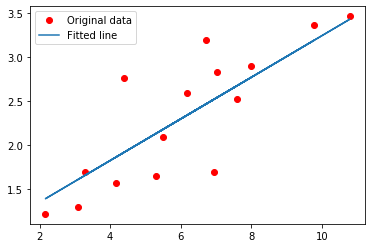

In [ ]:
# Plot the graph
predicted = model(torch.from_numpy(x_train)).detach().numpy()
plt.plot(x_train, y_train, 'ro', label='Original data') #ro：红色 散点
plt.plot(x_train, predicted, label='Fitted line')
plt.legend()
plt.show()

In [ ]:
# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')
# state_dict() 是一个返回模型所有可学习参数的字典。这个字典的键是每一层的名称（如 layer1.weight, layer1.bias），而值是对应层的参数（权重或偏置）。

In [37]:
#### feedforward_neural_network

In [5]:
# Hyper-parameters 
input_size = 28*28
hidden_size = 500
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [6]:
# MNIST dataset 
train_dataset = torchvision.datasets.MNIST(root='../../data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='../../data', 
                                          train=False, 
                                          transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)


100%|██████████| 9.91M/9.91M [00:03<00:00, 2.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 62.2kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.18MB/s]


In [ ]:
# Fully connected neural network with one hidden layer全连接神经网络
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)  
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss() #交叉熵损失
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  

In [ ]:
# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):  #enumerate打印进度 获得当前批次的索引。
        # Move tensors to the configured device
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))


Epoch [1/5], Step [100/600], Loss: 0.4459
Epoch [1/5], Step [200/600], Loss: 0.2850
Epoch [1/5], Step [300/600], Loss: 0.2269
Epoch [1/5], Step [400/600], Loss: 0.2231
Epoch [1/5], Step [500/600], Loss: 0.1532
Epoch [1/5], Step [600/600], Loss: 0.2710
Epoch [2/5], Step [100/600], Loss: 0.1489
Epoch [2/5], Step [200/600], Loss: 0.3242
Epoch [2/5], Step [300/600], Loss: 0.0676
Epoch [2/5], Step [400/600], Loss: 0.1021
Epoch [2/5], Step [500/600], Loss: 0.1104
Epoch [2/5], Step [600/600], Loss: 0.1063
Epoch [3/5], Step [100/600], Loss: 0.1364
Epoch [3/5], Step [200/600], Loss: 0.0564
Epoch [3/5], Step [300/600], Loss: 0.0538
Epoch [3/5], Step [400/600], Loss: 0.0471
Epoch [3/5], Step [500/600], Loss: 0.0753
Epoch [3/5], Step [600/600], Loss: 0.0154
Epoch [4/5], Step [100/600], Loss: 0.0461
Epoch [4/5], Step [200/600], Loss: 0.0333
Epoch [4/5], Step [300/600], Loss: 0.1161
Epoch [4/5], Step [400/600], Loss: 0.0276
Epoch [4/5], Step [500/600], Loss: 0.0704
Epoch [4/5], Step [600/600], Loss:

In [ ]:
# Test the model
# In test phase, we don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #取第1维（类别维度）上最大分数的位置（即预测类别）
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the 10000 test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy of the network on the 10000 test images: 97.74 %
